# Исследование данных о датчиках пожарной сигнализации

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [140]:
df = pd.read_csv('../data/smoke_detector_task.csv', sep = ",", encoding="utf-8")

In [141]:
df.head(20)

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0.0,400.0,12306.0,18520,939.735,0.00,0.00,0.0,0.000,0.000,0,No
1,1,1654733332,20.015,56.67,0.0,400.0,12345.0,18651,939.744,0.00,0.00,0.0,0.000,0.000,1,No
2,2,1654733333,20.029,55.96,0.0,400.0,12374.0,18764,939.738,0.00,0.00,0.0,0.000,0.000,2,No
3,3,1654733334,20.044,55.28,0.0,400.0,12390.0,18849,939.736,0.00,0.00,0.0,0.000,0.000,3,No
4,4,1654733335,20.059,54.69,0.0,400.0,12403.0,18921,939.744,0.00,0.00,0.0,0.000,0.000,4,No
5,5,1654733336,20.073,54.12,0.0,400.0,12419.0,18998,939.725,0.00,0.00,0.0,0.000,0.000,5,No
6,6,1654733337,20.088,53.61,0.0,400.0,12432.0,19058,939.738,0.00,0.00,0.0,0.000,0.000,6,No
7,7,1654733338,20.103,53.20,0.0,400.0,12439.0,19114,939.758,0.00,0.00,0.0,0.000,0.000,7,No
8,8,1654733339,20.117,52.81,0.0,400.0,12448.0,19155,939.758,0.00,0.00,0.0,0.000,0.000,8,No
9,9,1654733340,20.132,52.46,0.0,400.0,12453.0,19195,939.756,0.90,3.78,0.0,4.369,2.780,9,No


Стоит удалить параметры "Unnamed:0","UTC" так как он не несет смысловой нагрузки

In [142]:
df = df.drop("Unnamed: 0", axis=1)
df = df.drop("UTC", axis=1)

array([[<Axes: title={'center': 'CNT'}>]], dtype=object)

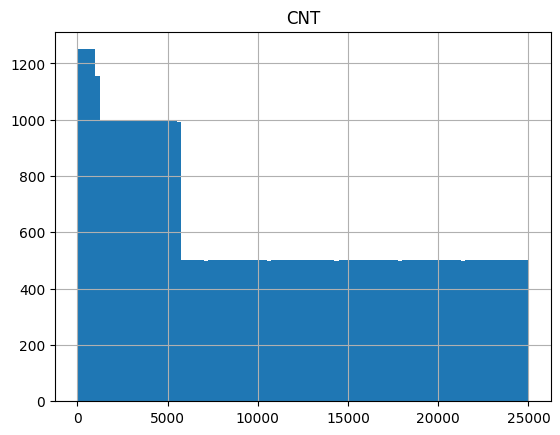

In [143]:
df.hist("CNT", bins=100)

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature[C]  62484 non-null  float64
 1   Humidity[%]     62383 non-null  float64
 2   TVOC[ppb]       62009 non-null  float64
 3   eCO2[ppm]       62305 non-null  float64
 4   Raw H2          62519 non-null  float64
 5   Raw Ethanol     62630 non-null  int64  
 6   Pressure[hPa]   62603 non-null  float64
 7   PM1.0           62630 non-null  float64
 8   PM2.5           62313 non-null  float64
 9   NC0.5           62630 non-null  float64
 10  NC1.0           62378 non-null  float64
 11  NC2.5           62630 non-null  float64
 12  CNT             62630 non-null  int64  
 13  Fire Alarm      62630 non-null  str    
dtypes: float64(11), int64(2), str(1)
memory usage: 6.7 MB


**Обработка пропущенных значений**

In [145]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

TVOC[ppb]         0.991538
eCO2[ppm]         0.518921
PM2.5             0.506147
NC1.0             0.402363
Humidity[%]       0.394380
Temperature[C]    0.233115
Raw H2            0.177231
Pressure[hPa]     0.043110
Raw Ethanol       0.000000
PM1.0             0.000000
NC0.5             0.000000
NC2.5             0.000000
CNT               0.000000
Fire Alarm        0.000000
dtype: float64

Чтобы заполнить пропущенные значения, необходимо узнать статистику данных

In [146]:
df.describe()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT
count,62484.000000,62383.000000,62009.000000,62305.000000,62519.000000,62630.000000,62603.000000,62630.000000,62313.000000,62630.000000,62378.000000,62630.000000,62630.000000
mean,15.972252,48.536969,1944.124030,670.574994,12942.383835,19754.257912,938.627644,100.594309,184.443467,491.463608,203.382660,80.049042,10511.386157
std,14.361206,8.868993,7819.668069,1909.675941,272.531480,609.513156,1.331169,922.524245,1976.590473,4265.661251,2214.719662,1083.383189,7597.870997
min,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000500,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000
50%,20.130000,50.140000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.942000,0.044000,9336.000000
75%,25.410000,53.240000,1189.000000,438.000000,13108.000000,20078.000000,939.417000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000
max,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000


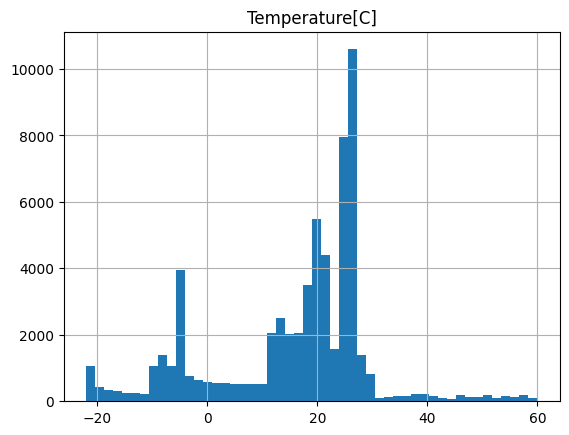

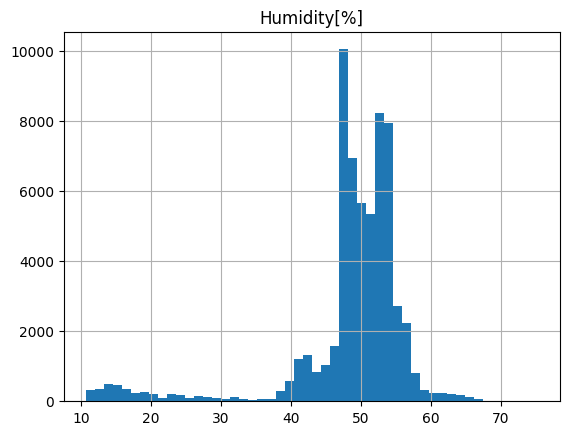

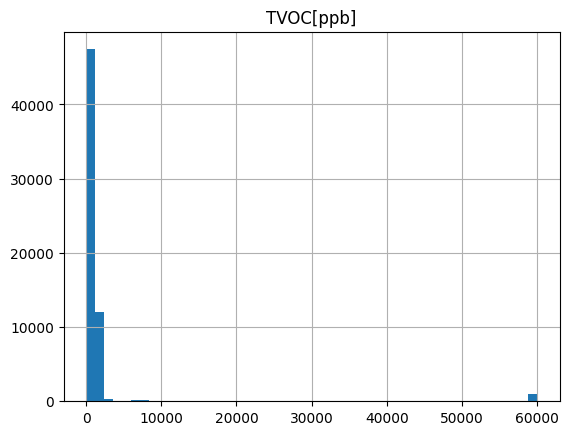

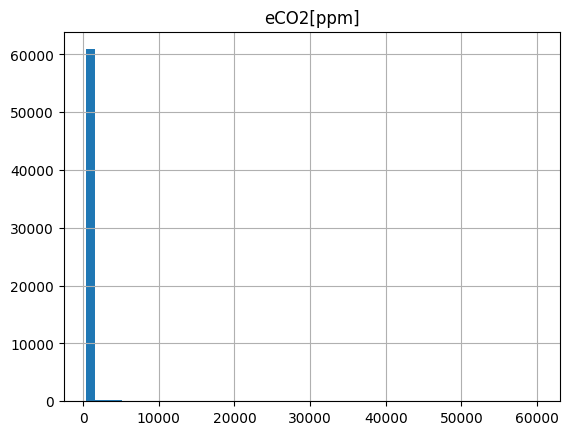

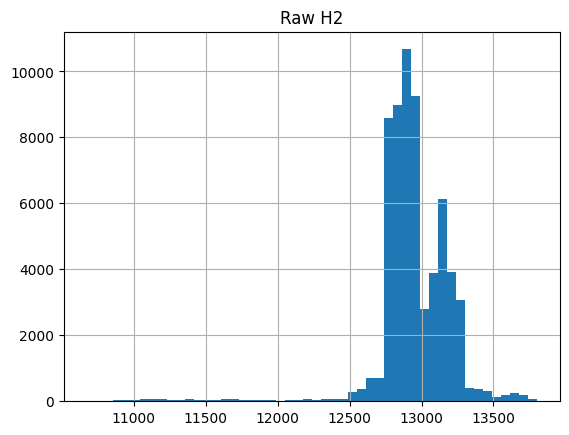

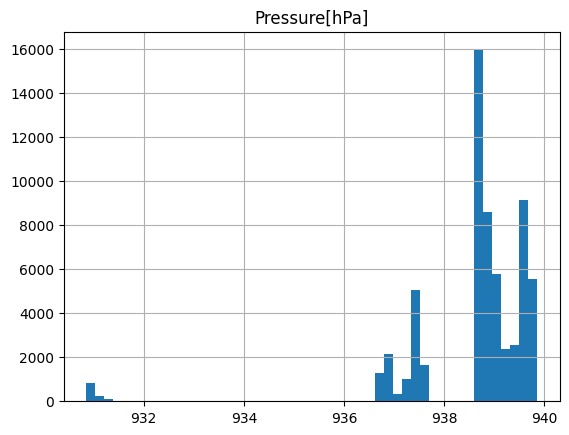

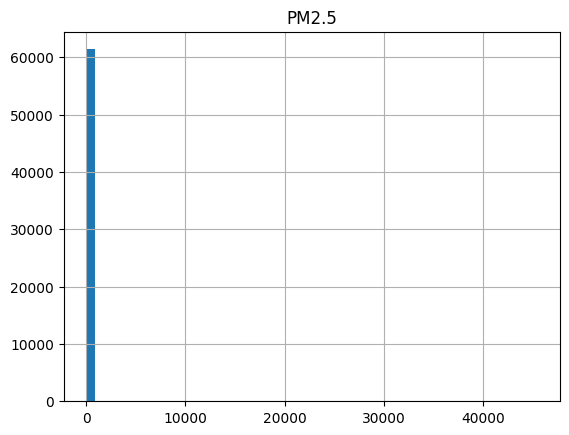

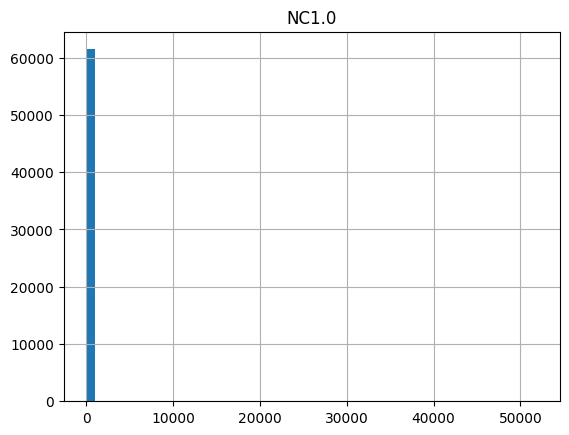

In [147]:
columns = ["Temperature[C]","Humidity[%]","TVOC[ppb]","eCO2[ppm]","Raw H2","Pressure[hPa]","PM2.5","NC1.0"]

for column in columns:
    df.hist(column, bins=50)

**Вывод:**

- Пропуски лучше будет заполнить медианой, так как, судя по графикам, в данных есть выбросы

In [148]:
for col in columns:
    df[col] = df[col].fillna(df[col].median())

In [149]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

Temperature[C]    0.0
Humidity[%]       0.0
TVOC[ppb]         0.0
eCO2[ppm]         0.0
Raw H2            0.0
Raw Ethanol       0.0
Pressure[hPa]     0.0
PM1.0             0.0
PM2.5             0.0
NC0.5             0.0
NC1.0             0.0
NC2.5             0.0
CNT               0.0
Fire Alarm        0.0
dtype: float64

Все пустые значения заполнены

**Проверим корректность типов данных, тип которых, возможно, стоит заменить на int**

In [150]:
(df["eCO2[ppm]"] % 1 == 0).all()

np.True_

In [151]:
(df["TVOC[ppb]"] % 1 == 0).all()

np.True_

In [152]:
(df["Raw H2"] % 1 == 0).all()

np.True_

In [153]:
(df["Raw Ethanol"] % 1 == 0).all()

np.True_

Значения во всех вышеперечисленных столбцах можно привести к типу int, так как дробная часть у всех элементов столбцов равна 0

In [154]:
columns = ["eCO2[ppm]", "TVOC[ppb]", "Raw H2", "Raw Ethanol"]

for column in columns:
    df[column] = df[column].astype('int32')

Тип данных в столбце "Fire Alarm" стоит заменить на 0 и 1

In [155]:
df['Fire Alarm'] = df['Fire Alarm'].map({'No': 0, 'Yes': 1})

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature[C]  62630 non-null  float64
 1   Humidity[%]     62630 non-null  float64
 2   TVOC[ppb]       62630 non-null  int32  
 3   eCO2[ppm]       62630 non-null  int32  
 4   Raw H2          62630 non-null  int32  
 5   Raw Ethanol     62630 non-null  int32  
 6   Pressure[hPa]   62630 non-null  float64
 7   PM1.0           62630 non-null  float64
 8   PM2.5           62630 non-null  float64
 9   NC0.5           62630 non-null  float64
 10  NC1.0           62630 non-null  float64
 11  NC2.5           62630 non-null  float64
 12  CNT             62630 non-null  int64  
 13  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int32(4), int64(2)
memory usage: 5.7 MB


Все данные в корректном формате

Проверка данных на дубликаты

In [157]:
df.duplicated().sum()

np.int64(3)

Дубликаты отсутствуют

## Визуальный анализ данных

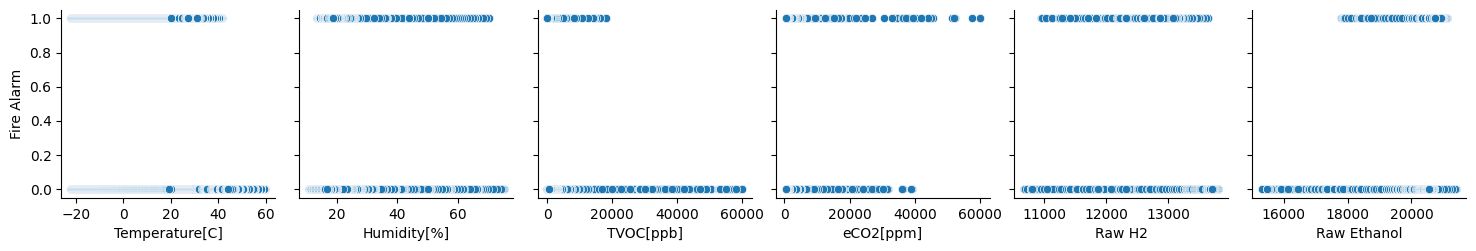

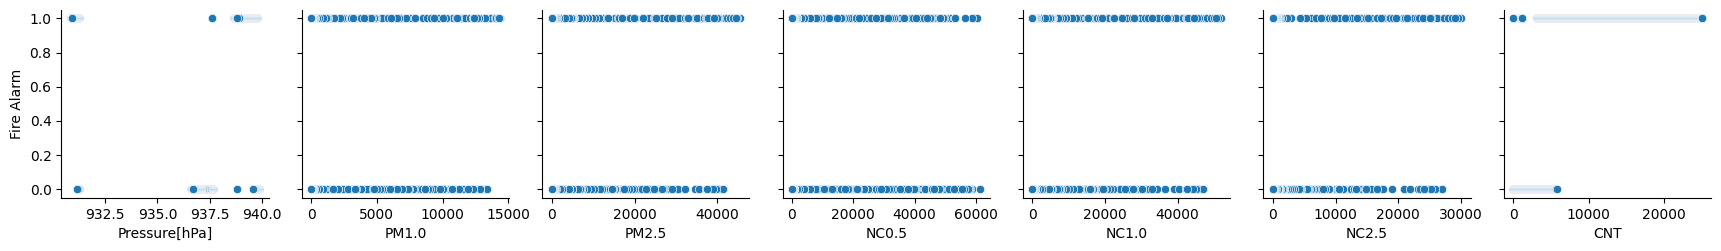

In [158]:
sns.pairplot(df, y_vars=["Fire Alarm"], x_vars=["Temperature[C]","Humidity[%]","TVOC[ppb]","eCO2[ppm]","Raw H2","Raw Ethanol"])
sns.pairplot(df, y_vars=["Fire Alarm"], x_vars=["Pressure[hPa]", "PM1.0","PM2.5","NC0.5","NC1.0","NC2.5","CNT"])

**Вывод:**

- Пожарная сигнализация не срабатывает, если параметр "TVOC[ppb]" больше 20000
- Пожарная сигнализация не срабатывает, если параметр "Raw Ethanol" меньше 18000
- Пожарная сигнализация срабатывает, если параметр "eCO2[ppm]" больше 4000
- Пожарная сигнализация срабатывает, если параметр "CNT" больше ~7000

<Axes: >

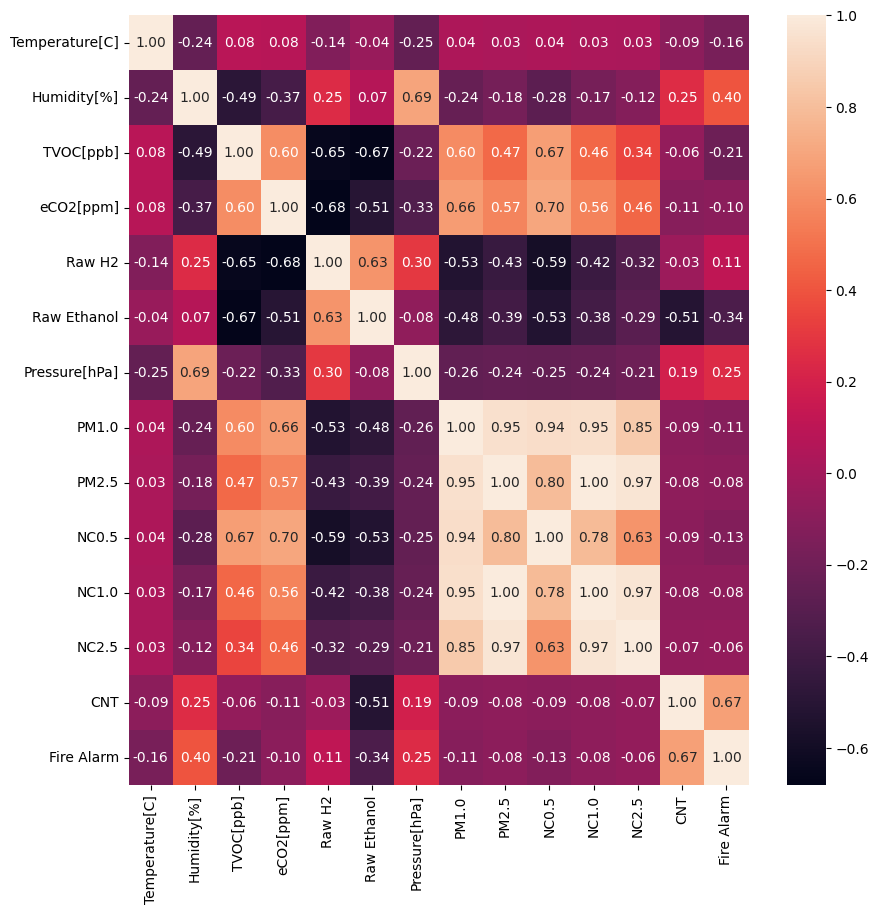

In [159]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot = True, fmt = '.2f')

**Выводы:**

- Очевидна прямая связь с параметром CNT и срабатыванием пожарной сигнализации;
- Видно прямую связь с влажностью и срабатыванием пожарной сигнализации;
- Возможна связь параметров "UTC" и "Raw Ethanol" с тем, что пожарная сигнализация не сработает;
- С параметром "Humidity" коррелирует параметр "Pressure", которые может косвенно влиять на срабатывание пожарной сигнализации

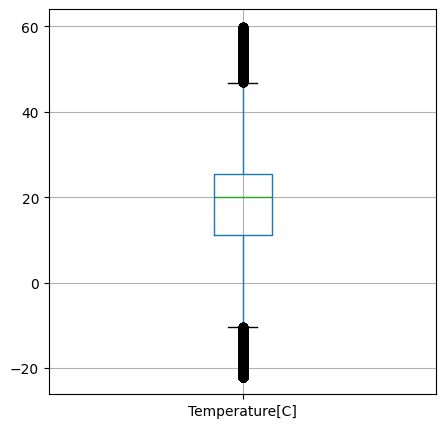

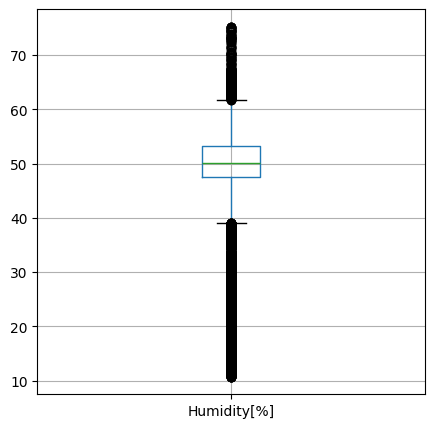

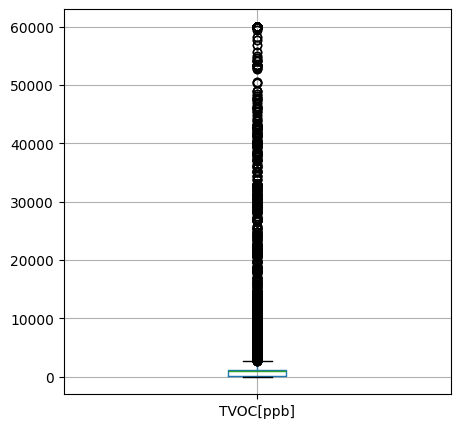

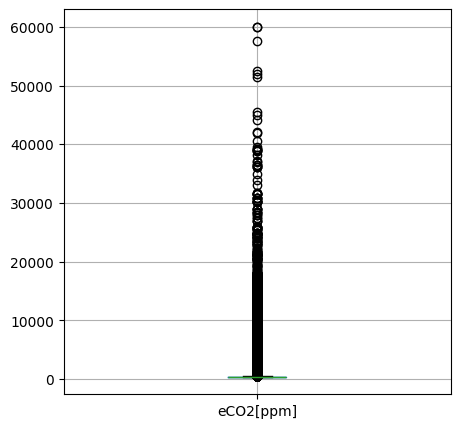

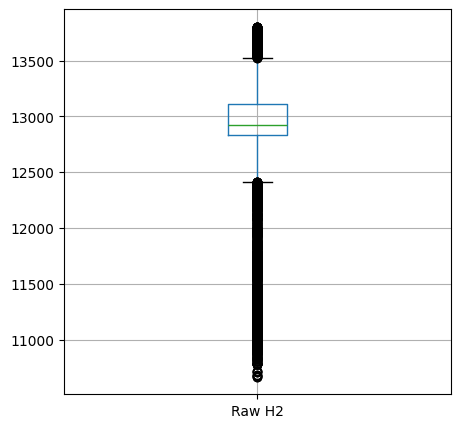

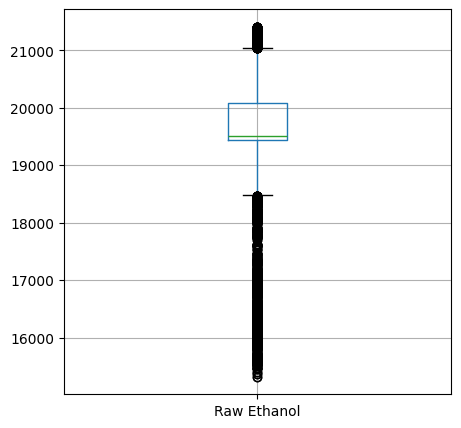

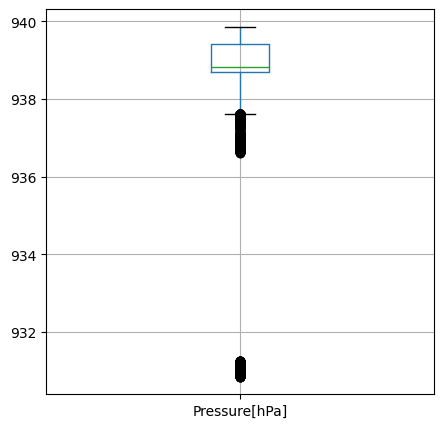

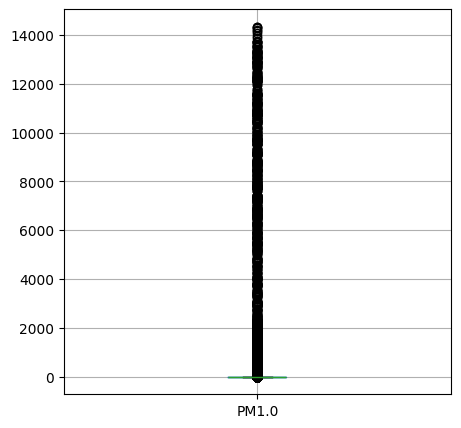

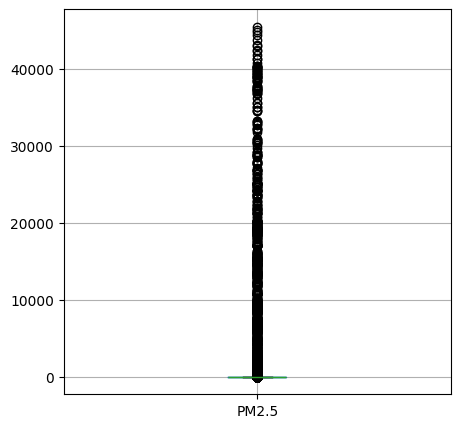

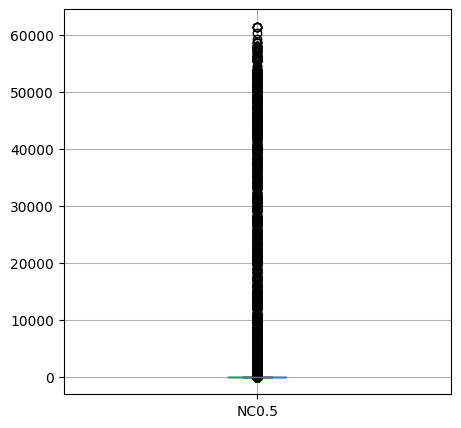

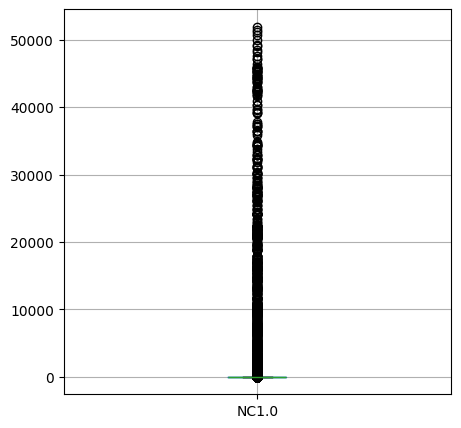

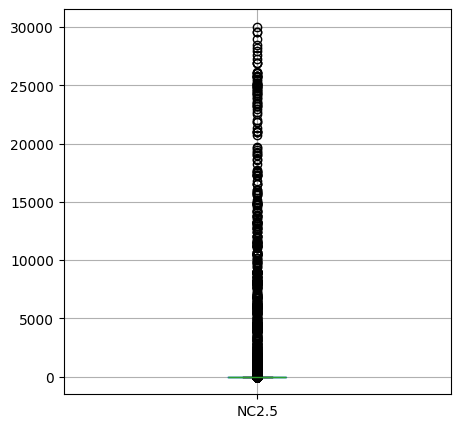

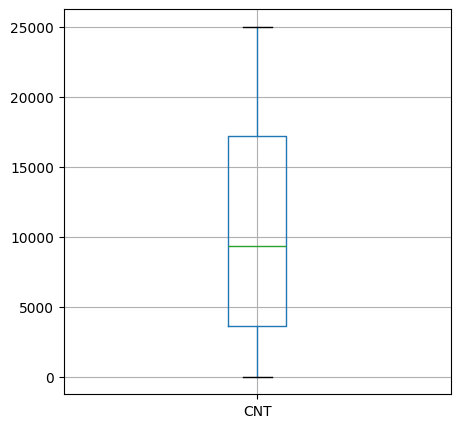

In [161]:
columns = ["Temperature[C]","Humidity[%]","TVOC[ppb]","eCO2[ppm]","Raw H2","Raw Ethanol","Pressure[hPa]","PM1.0","PM2.5","NC0.5","NC1.0","NC2.5","CNT"]

for column in columns:
    plt.figure(figsize=(5, 5))
    df.boxplot(column)
    plt.show()

**Вывод:**

- Почти по всем параметрам достаточно много выбросов
- Выбросами обделен параметр CNT

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[df.columns] = scaler.fit_transform(df)

<Axes: >

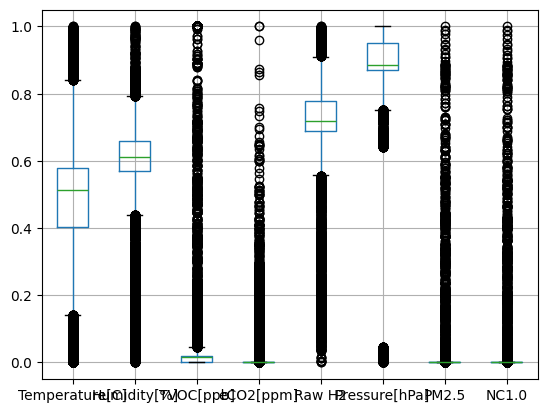

In [164]:
columns = ["Temperature[C]","Humidity[%]","TVOC[ppb]","eCO2[ppm]","Raw H2","Pressure[hPa]","PM2.5","NC1.0"]
df.boxplot(columns)

In [166]:
df.to_csv("../data/Classification_smoke_detectors_filtered.csv")